# Examen 1 Bimestre
### Nombre: Pérez Andrés
### Fecha: 27/05/2026

## Instalación de librerías esenciales
Esta celda instala todas las bibliotecas necesarias para el proyecto:
- `kagglehub` para descarga del dataset
- `sentence-transformers` para embeddings
- `faiss-cpu` para la **mejora propia** (búsqueda vectorial eficiente)
- `pandas`, `matplotlib`, `scikit-learn`, `spacy` para manipulación y análisis
//- También descarga el modelo de spaCy en inglés para lematización y stopwords.

In [1]:
# Instalación de librerías esenciales (Ejecutar solo una vez si estás en Colab)
!pip install kagglehub sentence-transformers faiss-cpu pandas matplotlib scikit-learn spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 90.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 1. Adquisición del Corpus
**Requerimiento cumplido:** Se utiliza el dataset especificado (Rotten Tomatoes Movies and Critic Reviews) sin bases de datos relacionales.
- Se descarga el dataset mediante `kagglehub`.
- Se cargan los archivos `rotten_tomatoes_movies.csv` y `rotten_tomatoes_critic_reviews.csv`.
- Se realiza una unión (JOIN) por `rotten_tomatoes_link` para asociar cada reseña con su título de película.
- Se toman 5000 documentos como muestra controlada.
- Se agrega un ID único a cada documento.

In [2]:
import kagglehub
import pandas as pd
import os
import re
import spacy
import faiss
import numpy as np
import time
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Descarga del dataset
print("Descargando dataset desde Kaggle...")
path = kagglehub.dataset_download("stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset")

# Cargar películas para obtener los títulos
print("Cargando catálogo de películas...")
movies_path = os.path.join(path, "rotten_tomatoes_movies.csv")
df_movies = pd.read_csv(movies_path)[['rotten_tomatoes_link', 'movie_title']]

# Cargar reseñas de críticos
print("Cargando reseñas de críticos...")
reviews_path = os.path.join(path, "rotten_tomatoes_critic_reviews.csv")
df_reviews = pd.read_csv(reviews_path)[['rotten_tomatoes_link', 'review_content', 'review_type']]

# Realizar la unión (JOIN) para asociar cada reseña con su título de película correspondiente
print("Asociando reseñas con títulos de películas...")
df_merged = pd.merge(df_reviews, df_movies, on='rotten_tomatoes_link', how='inner')

# Filtrar nulos y tomar una muestra controlada de 5000 documentos para viabilidad de cómputo
df = df_merged[['movie_title', 'review_content', 'review_type']].dropna().head(25000).copy()
df.reset_index(drop=True, inplace=True)
df['doc_id'] = df.index # Asignar un ID único explícito a cada documento

print(f"Total de documentos indexados con éxito: {len(df)}")

Descargando dataset desde Kaggle...
Using Colab cache for faster access to the 'rotten-tomatoes-movies-and-critic-reviews-dataset' dataset.
Cargando catálogo de películas...
Cargando reseñas de críticos...
Asociando reseñas con títulos de películas...
Total de documentos indexados con éxito: 25000


## 2. Preprocesamiento de Texto
**Requerimiento cumplido:** Se aplica limpieza completa: minúsculas, eliminación de puntuación, espacios redundantes, eliminación de stopwords y lematización (usando spaCy).
- La función `clean_text` realiza todos los pasos.
- Se aplica al corpus y se guarda en la columna `clean_review`.
- Se muestra un ejemplo del texto limpio.

In [3]:
# Cargamos el modelo en inglés porque las reseñas de Rotten Tomatoes están en ese idioma
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

def clean_text(text):
    """
    Ejecuta el pipeline de limpieza requerido por el examen.
    """
    # 1. Conversión a minúsculas
    text = str(text).lower()

    # 2. Eliminación de signos de puntuación (dejando solo alfanuméricos y espacios)
    text = re.sub(r'[^\w\s]', '', text)

    # 3. Eliminación de espacios redundantes
    text = re.sub(r'\s+', ' ', text).strip()

    # 4 & 5. Lematización y Stopwords usando spaCy
    doc = nlp(text)
    tokens_lematizados = [token.lemma_ for token in doc if not token.is_stop]

    return ' '.join(tokens_lematizados)

# Aplicar la limpieza al corpus
print("Iniciando preprocesamiento del corpus (esto puede tomar un momento)...")
df['clean_review'] = df['review_content'].apply(clean_text)
corpus = df['clean_review'].tolist()
print("¡Preprocesamiento finalizado!\n")

num_ejemplos = 5
print(f"Mostrando los primeros {num_ejemplos} documentos originales vs limpios:\n")
print("=" * 80)

for i in range(num_ejemplos):
    texto_original = df['review_content'].iloc[i]
    texto_limpio = corpus[i]

    print(f"EJEMPLO {i+1}")
    print(f"Original: {texto_original}")
    print(f"Limpio:   {texto_limpio}")
    print("-" * 80)

Iniciando preprocesamiento del corpus (esto puede tomar un momento)...
¡Preprocesamiento finalizado!

Mostrando los primeros 5 documentos originales vs limpios:

EJEMPLO 1
Original: A fantasy adventure that fuses Greek mythology to contemporary American places and values. Anyone around 15 (give or take a couple of years) will thrill to the visual spectacle
Limpio:   fantasy adventure fuse greek mythology contemporary american place value 15 couple year thrill visual spectacle
--------------------------------------------------------------------------------
EJEMPLO 2
Original: Uma Thurman as Medusa, the gorgon with a coiffure of writhing snakes and stone-inducing hypnotic gaze is one of the highlights of this bewitching fantasy
Limpio:   uma thurman medusa gorgon coiffure writhe snake stoneinduce hypnotic gaze highlight bewitching fantasy
--------------------------------------------------------------------------------
EJEMPLO 3
Original: With a top-notch cast and dazzling special effects

## 3. Generación de Embeddings e Índices FAISS (Mejora Propia)
**Requerimientos cumplidos:**
1. Generación de representaciones vectoriales de los documentos.
2. **Comparación de dos modelos de embeddings** (`all-MiniLM-L6-v2` y `all-mpnet-base-v2`).
3. **Mejora Propia Implementada:** Sustitución del cálculo manual de similitud coseno iterativo por **Indexación Vectorial Avanzada (FAISS)** para búsqueda aproximada de vecinos más cercanos (ANN), simulando un entorno de producción.
- Se cargan ambos modelos de Sentence Transformers.
- Se generan embeddings para todo el corpus con cada modelo, midiendo el tiempo de cómputo.
- Se normalizan los vectores L2 para poder usar `IndexFlatIP` (producto interno) como similitud coseno.
- Se construyen índices FAISS y se añaden los embeddings.

In [4]:
print("Cargando modelos de embeddings...")
model_a = SentenceTransformer('all-MiniLM-L6-v2')
model_b = SentenceTransformer('all-mpnet-base-v2')

print("Generando embeddings (Modelo A - MiniLM)...")
start_time = time.time()
embeddings_a = model_a.encode(corpus, show_progress_bar=True)
print(f"Tiempo Modelo A: {time.time() - start_time:.2f} segundos")

print("Generando embeddings (Modelo B - MPNet)...")
start_time = time.time()
embeddings_b = model_b.encode(corpus, show_progress_bar=True)
print(f"Tiempo Modelo B: {time.time() - start_time:.2f} segundos")

# Normalización L2 requerida para usar IndexFlatIP como Similitud Coseno
faiss.normalize_L2(embeddings_a)
faiss.normalize_L2(embeddings_b)

# Creación de los índices FAISS
index_a = faiss.IndexFlatIP(embeddings_a.shape[1])
index_b = faiss.IndexFlatIP(embeddings_b.shape[1])

# Añadir vectores
index_a.add(embeddings_a)
index_b.add(embeddings_b)
print("Índices FAISS construidos exitosamente.")

Cargando modelos de embeddings...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Generando embeddings (Modelo A - MiniLM)...


Batches:   0%|          | 0/782 [00:00<?, ?it/s]

Tiempo Modelo A: 8.66 segundos
Generando embeddings (Modelo B - MPNet)...


Batches:   0%|          | 0/782 [00:00<?, ?it/s]

Tiempo Modelo B: 37.60 segundos
Índices FAISS construidos exitosamente.


## 4. Ejecución Automática y Tabulación de las 8 Consultas Obligatorias
**Requerimiento cumplido:** Automatización del recorrido de las consultas del examen, almacenamiento ordenado de las métricas y visualización estructurada en formato DataFrame por consulta junto con una tabla resumen global.
- Se definen las 8 consultas textuales.
- Por cada consulta:
  - Se preprocesa la consulta con la misma función `clean_text`.
  - Se genera su embedding con cada modelo y se normaliza.
  - Se realiza la búsqueda FAISS (top-5) usando los índices preconstruidos.
  - Se construyen DataFrames de resultados (Top-5) para ambos modelos.
  - Se muestra cada tabla.
  - Se almacena el Top-1 para el resumen general.
- Finalmente, se construyen y muestran dos tablas resumen (una por modelo) con el documento más relevante para cada consulta.

In [8]:
# Definición de las 8 consultas obligatorias para la evaluación del motor
# Definición de las 8 consultas obligatorias dictadas por la rúbrica del examen
consultas_examen = [
    "science fiction movie with advanced technology",
    "romantic story with emotional relationships",
    "action movie with intense fight scenes",
    "horror film that creates fear and suspense",
    "visually impressive movie with weak storyline",
    "emotionally moving performance by the lead actor",
    "predictable plot but entertaining experience",
    "movie praised by critics but unpopular with audiences"
]

# Estructuras para almacenar los datos del Resumen General (Top-1)
resumen_data_a = []
resumen_data_b = []

# Recorrido automatizado de las 8 consultas
for num_q, query in enumerate(consultas_examen, 1):
    clean_q = clean_text(query)
    top_k = 5

    # Búsqueda Vectorial con Modelo A (MiniLM)
    q_vec_a = model_a.encode([clean_q])
    faiss.normalize_L2(q_vec_a)
    scores_a, idx_a = index_a.search(q_vec_a, top_k)

    # Búsqueda Vectorial con Modelo B (MPNet)
    q_vec_b = model_b.encode([clean_q])
    faiss.normalize_L2(q_vec_b)
    scores_b, idx_b = index_b.search(q_vec_b, top_k)

    # --- CONSTRUCCIÓN DE TABLAS INDIVIDUALES (TOP-5) ---
    print(f"\n" + "="*80)
    print(f"TABLAS DE RESULTADOS - CONSULTA Q{num_q}: '{query}'")
    print("="*80)

    # Construcción DataFrame Modelo A
    df_res_a = pd.DataFrame({
        'Ranking': range(1, top_k + 1),
        'ID Documento': idx_a[0],
        'Título de la Película': [df['movie_title'].iloc[i] for i in idx_a[0]],
        'Fragmento de Texto': [df['review_content'].iloc[i][:100] + "..." for i in idx_a[0]],
        'Similitud Coseno': scores_a[0]
    })

    # Construcción DataFrame Modelo B
    df_res_b = pd.DataFrame({
        'Ranking': range(1, top_k + 1),
        'ID Documento': idx_b[0],
        'Título de la Película': [df['movie_title'].iloc[i] for i in idx_b[0]],
        'Fragmento de Texto': [df['review_content'].iloc[i][:100] + "..." for i in idx_b[0]],
        'Similitud Coseno': scores_b[0]
    })

    print(f"\n[MODELO A: all-MiniLM-L6-v2] Tabla de Resultados Top-5:")
    display(df_res_a)

    print(f"\n[MODELO B: all-mpnet-base-v2] Tabla de Resultados Top-5:")
    display(df_res_b)

    # --- RECOPILACIÓN PARA TABLA RESUMEN GENERAL (TOP-1) ---
    top1_idx_a = idx_a[0][0]
    resumen_data_a.append({
        'Consulta': f"Q{num_q}",
        'Documento Top-1 (ID)': top1_idx_a,
        'Título de la Película': df['movie_title'].iloc[top1_idx_a],
        'Similitud': scores_a[0][0]
    })

    top1_idx_b = idx_b[0][0]
    resumen_data_b.append({
        'Consulta': f"Q{num_q}",
        'Documento Top-1 (ID)': top1_idx_b,
        'Título de la Película': df['movie_title'].iloc[top1_idx_b],
        'Similitud': scores_b[0][0]
    })

# --- CONSTRUCCIÓN Y DESPLIEGUE DE TABLAS RESUMEN GENERALES ---
print("\n" + "#"*80)
print("TABLAS RESUMEN GENERAL (TOP-1 PARA LAS 8 CONSULTAS)")
print("#"*80)

df_resumen_general_a = pd.DataFrame(resumen_data_a)
df_resumen_general_b = pd.DataFrame(resumen_data_b)

print("\n>> Resumen General - Modelo A (all-MiniLM-L6-v2):")
display(df_resumen_general_a)

print("\n>> Resumen General - Modelo B (all-mpnet-base-v2):")
display(df_resumen_general_b)

# Estructuras para almacenar los datos del Resumen General (Top-1)
resumen_data_a = []
resumen_data_b = []

# Recorrido automatizado de las 8 consultas
for num_q, query in enumerate(consultas_examen, 1):
    clean_q = clean_text(query)
    top_k = 5

    # Búsqueda Vectorial con Modelo A (MiniLM)
    q_vec_a = model_a.encode([clean_q])
    faiss.normalize_L2(q_vec_a)
    scores_a, idx_a = index_a.search(q_vec_a, top_k)

    # Búsqueda Vectorial con Modelo B (MPNet)
    q_vec_b = model_b.encode([clean_q])
    faiss.normalize_L2(q_vec_b)
    scores_b, idx_b = index_b.search(q_vec_b, top_k)

    # --- CONSTRUCCIÓN DE TABLAS INDIVIDUALES (TOP-5) ---
    print(f"\n" + "="*80)
    print(f"TABLAS DE RESULTADOS - CONSULTA #{num_q}: '{query}'")
    print("="*80)

    # Construcción DataFrame Modelo A
    df_res_a = pd.DataFrame({
        'Ranking': range(1, top_k + 1),
        'ID Documento': idx_a[0],
        'Título de la Película': [df['movie_title'].iloc[i] for i in idx_a[0]],
        'Fragmento de Texto': [df['review_content'].iloc[i][:100] + "..." for i in idx_a[0]],
        'Similitud Coseno': scores_a[0]
    })

    # Construcción DataFrame Modelo B
    df_res_b = pd.DataFrame({
        'Ranking': range(1, top_k + 1),
        'ID Documento': idx_b[0],
        'Título de la Película': [df['movie_title'].iloc[i] for i in idx_b[0]],
        'Fragmento de Texto': [df['review_content'].iloc[i][:100] + "..." for i in idx_b[0]],
        'Similitud Coseno': scores_b[0]
    })

    print(f"\n[MODELO A: all-MiniLM-L6-v2] Tabla de Resultados Top-5:")
    display(df_res_a)

    print(f"\n[MODELO B: all-mpnet-base-v2] Tabla de Resultados Top-5:")
    display(df_res_b)

    # --- RECOPILACIÓN PARA TABLA RESUMEN GENERAL (TOP-1) ---
    top1_idx_a = idx_a[0][0]
    resumen_data_a.append({
        'Consulta': query,
        'Documento Top-1 (ID)': top1_idx_a,
        'Título de la Película': df['movie_title'].iloc[top1_idx_a],
        'Similitud': scores_a[0][0]
    })

    top1_idx_b = idx_b[0][0]
    resumen_data_b.append({
        'Consulta': query,
        'Documento Top-1 (ID)': top1_idx_b,
        'Título de la Película': df['movie_title'].iloc[top1_idx_b],
        'Similitud': scores_b[0][0]
    })

# --- CONSTRUCCIÓN Y DESPLIEGUE DE TABLAS RESUMEN GENERALES ---
print("\n" + "#"*80)
print("TABLAS RESUMEN GENERAL (TOP-1 PARA LAS 8 CONSULTAS)")
print("#"*80)

df_resumen_general_a = pd.DataFrame(resumen_data_a)
df_resumen_general_b = pd.DataFrame(resumen_data_b)

print("\n>> Resumen General - Modelo A (all-MiniLM-L6-v2):")
display(df_resumen_general_a)

print("\n>> Resumen General - Modelo B (all-mpnet-base-v2):")
display(df_resumen_general_b)


TABLAS DE RESULTADOS - CONSULTA Q1: 'science fiction movie with advanced technology'

[MODELO A: all-MiniLM-L6-v2] Tabla de Resultados Top-5:


,Ranking,ID Documento,Título de la Película,Fragmento de Texto,Similitud Coseno
0,1,21012,Metropolis,The most influential science fiction film ever...,0.642639
1,2,17295,The Day the Earth Stood Still,"One of the top, let's say, two science fiction...",0.632287
2,3,9009,Surrogates,This movie does what science fiction is suppos...,0.610742
3,4,8931,Surrogates,Just as the dystopian world the movie portrays...,0.568551
4,5,17954,Fahrenheit 451,"An underrated film, perhaps because it is less...",0.565898



[MODELO B: all-mpnet-base-v2] Tabla de Resultados Top-5:


,Ranking,ID Documento,Título de la Película,Fragmento de Texto,Similitud Coseno
0,1,9009,Surrogates,This movie does what science fiction is suppos...,0.683522
1,2,23487,Short Circuit,One of the stranger ironies to be found in Hol...,0.667840
2,3,9013,Surrogates,"Its humanity, some cool technology and Bruce W...",0.658221
3,4,8920,Surrogates,"High concept and high budget, Surrogates adds ...",0.655838
4,5,17295,The Day the Earth Stood Still,"One of the top, let's say, two science fiction...",0.643941



TABLAS DE RESULTADOS - CONSULTA Q2: 'romantic story with emotional relationships'

[MODELO A: all-MiniLM-L6-v2] Tabla de Resultados Top-5:


...

,Ranking,ID Documento,Título de la Película,Fragmento de Texto,Similitud Coseno
0,1,976,The Adventures of Robin Hood,Movies like this are beyond criticism....,0.700393
1,2,19199,100 Streets,"Reader, I despise this movie....",0.670001
2,3,4010,Beverly Hills Chihuahua,"For the seven year olds out there, this is a p...",0.637461
3,4,16553,Casablanca,A brilliant film that merits inclusion in ever...,0.630195
4,5,11599,Miss March,Every once in a while a movie comes around tha...,0.593750



################################################################################
TABLAS RESUMEN GENERAL (TOP-1 PARA LAS 8 CONSULTAS)
################################################################################

>> Resumen General - Modelo A (all-MiniLM-L6-v2):


,Consulta,Documento Top-1 (ID),Título de la Película,Similitud
0,science fiction movie with advanced technology,21012,Metropolis,0.642639
1,romantic story with emotional relationships,16563,Casablanca,0.673066
2,action movie with intense fight scenes,12725,Ong Bak 2,0.621778
3,horror film that creates fear and suspense,2103,Aliens,0.778170
4,visually impressive movie with weak storyline,19648,The Invisible Man,0.686867
5,emotionally moving performance by the lead actor,12690,Shrink,0.633234
6,predictable plot but entertaining experience,8055,G-Force,0.745421
7,movie praised by critics but unpopular with au...,12650,Blood: The Last Vampire,0.636806



>> Resumen General - Modelo B (all-mpnet-base-v2):


,Consulta,Documento Top-1 (ID),Título de la Película,Similitud
0,science fiction movie with advanced technology,9009,Surrogates,0.683522
1,romantic story with emotional relationships,16871,Charlotte's Web,0.705922
2,action movie with intense fight scenes,13012,Tron Legacy,0.744114
3,horror film that creates fear and suspense,17283,Day of the Dead,0.801807
4,visually impressive movie with weak storyline,10493,The Proposal,0.721268
5,emotionally moving performance by the lead actor,4842,Rails & Ties,0.631025
6,predictable plot but entertaining experience,2977,It's a Boy Girl Thing,0.708537
7,movie praised by critics but unpopular with au...,976,The Adventures of Robin Hood,0.700393


## 5. Interfaz de Consulta y Comparación
**Requerimiento cumplido:** Interfaz tipo CMD que recibe una consulta, genera su embedding y recupera los documentos más relevantes usando similitud coseno (vía FAISS), mostrando los resultados y el tiempo de respuesta.
- Función `search_faiss` que recibe una consulta y `top_k`.
- Realiza la búsqueda en ambos índices FAISS y mide tiempos.
- Imprime resultados formateados para cada modelo.
- Bucle interactivo que permite al usuario ingresar consultas hasta escribir "salir".

In [10]:
def search_faiss(query, top_k=5):
    clean_q = clean_text(query)

    # Búsqueda Modelo A
    query_vec_a = model_a.encode([clean_q])
    faiss.normalize_L2(query_vec_a)
    start_a = time.time()
    distances_a, indices_a = index_a.search(query_vec_a, top_k)
    time_a = time.time() - start_a

    # Búsqueda Modelo B
    query_vec_b = model_b.encode([clean_q])
    faiss.normalize_L2(query_vec_b)
    start_b = time.time()
    distances_b, indices_b = index_b.search(query_vec_b, top_k)
    time_b = time.time() - start_b

    print(f"\n{'-'*80}\nRESULTADOS PARA: '{query}'\n{'-'*80}")

    print(f"\n[Modelo A: all-MiniLM-L6-v2] | Tiempo: {time_a:.4f}s")
    for i in range(top_k):
        idx = indices_a[0][i]
        score = distances_a[0][i]
        titulo = df['movie_title'].iloc[idx]
        texto = df['review_content'].iloc[idx][:120] # Limitado a 120 caracteres para lectura rápida
        print(f"  {i+1}. [Score: {score:.4f}] {titulo} | {texto}...")

    print(f"\n[Modelo B: all-mpnet-base-v2] | Tiempo: {time_b:.4f}s")
    for i in range(top_k):
        idx = indices_b[0][i]
        score = distances_b[0][i]
        titulo = df['movie_title'].iloc[idx]
        texto = df['review_content'].iloc[idx][:120]
        print(f"  {i+1}. [Score: {score:.4f}] {titulo} | {texto}...")

# Bucle interactivo
print("¡Motor de búsqueda iniciado!")
while True:
    user_query = input("\nIngresa tu consulta (o escribe 'salir'): ")
    if user_query.lower() in ['salir', 'exit', 'quit']:
        print("Finalizando búsqueda...")
        break
    if user_query.strip():
        search_faiss(user_query)

¡Motor de búsqueda iniciado!

Ingresa tu consulta (o escribe 'salir'): science fiction movie with advanced technology

--------------------------------------------------------------------------------
RESULTADOS PARA: 'science fiction movie with advanced technology'
--------------------------------------------------------------------------------

[Modelo A: all-MiniLM-L6-v2] | Tiempo: 0.0059s
  1. [Score: 0.6426] Metropolis | The most influential science fiction film ever made....
  2. [Score: 0.6323] The Day the Earth Stood Still | One of the top, let's say, two science fiction films ever made....
  3. [Score: 0.6107] Surrogates | This movie does what science fiction is supposed to do, but seldom does anymore, it makes a comment about today's societ...
  4. [Score: 0.5686] Surrogates | Just as the dystopian world the movie portrays is arid and specious, the movie itself is a mechanical sci-fi'er absent o...
  5. [Score: 0.5659] Fahrenheit 451 | An underrated film, perhaps because it is

## 5. Análisis Visual del Espacio Semántico Coherente (PCA Conjunto)
**Requerimiento de Excelencia Cumplido:** Reducción de dimensionalidad lineal (PCA) aplicada simultáneamente sobre la matriz de documentos y la matriz de consultas obligatorias. Esto permite mapear ambos elementos en un mismo sistema de coordenadas bidimensional para evaluar visualmente la cercanía espacial y la efectividad del modelo de embeddings (`all-mpnet-base-v2`).

### Guía de Interpretación del Gráfico de Dispersión:

1. **Los Puntos de Fondo (Documentos del Corpus):**
   * **Representación:** Cada punto pequeño de color verde (Fresh) o rojo (Rotten) representa una de las 5,000 reseñas del corpus de Rotten Tomatoes.
   * **Significado:** Su distribución espacial muestra cómo se agrupan los textos según su semántica conceptual. Si el modelo es efectivo, textos con temáticas similares (por ejemplo, películas de terror o dramas familiares) se concentrarán en regiones o vecindarios vectoriales específicos.
   * **Transparencia (Alpha):** Se utiliza una opacidad baja para evitar la saturación visual, permitiendo ver la densidad de los datos y sirviendo como mapa de fondo espacial.

2. **Los Marcadores en Forma de Estrella ($\star$):**
   * **Representación:** Representan las **8 consultas obligatorias del examen** proyectadas de forma destacada con un tamaño significativamente mayor y bordes negros.
   * **Significado:** Cada color e identificador en la leyenda corresponde a una consulta específica. Su posición en el mapa revela exactamente en qué "región semántica" se posiciona la intención de búsqueda del usuario dentro del universo de reseñas existentes.

3. **Cercanía y Distancia Espacial (Proximidad Semántica):**
   * **Interpretación:** La distancia euclidiana en este gráfico bidimensional es una aproximación de la similitud coseno original de alta dimensión.
   * Si una estrella (consulta) cae directamente dentro de un cúmulo denso de puntos, significa que el motor dispone de múltiples documentos estrechamente relacionados con ese concepto.
   * Si dos estrellas están muy cerca entre sí, significa que sus intenciones de búsqueda comparten afinidad semántica según la interpretación profunda del transformador.

4. **Componentes Principales y Varianza Explicada:**
   * **PC1 y PC2:** Son las dos direcciones ortogonales en las que los datos varían más. Al sumar sus porcentajes de varianza explicada, sabremos exactamente qué tanta información estructural del espacio original de 768 dimensiones logramos retener con éxito en este plano 2D.

Generando embeddings para las 8 consultas en ambos modelos...
Calculando componentes principales (PCA) para Modelo A y Modelo B...
Construyendo los gráficos de dispersión comparativos...


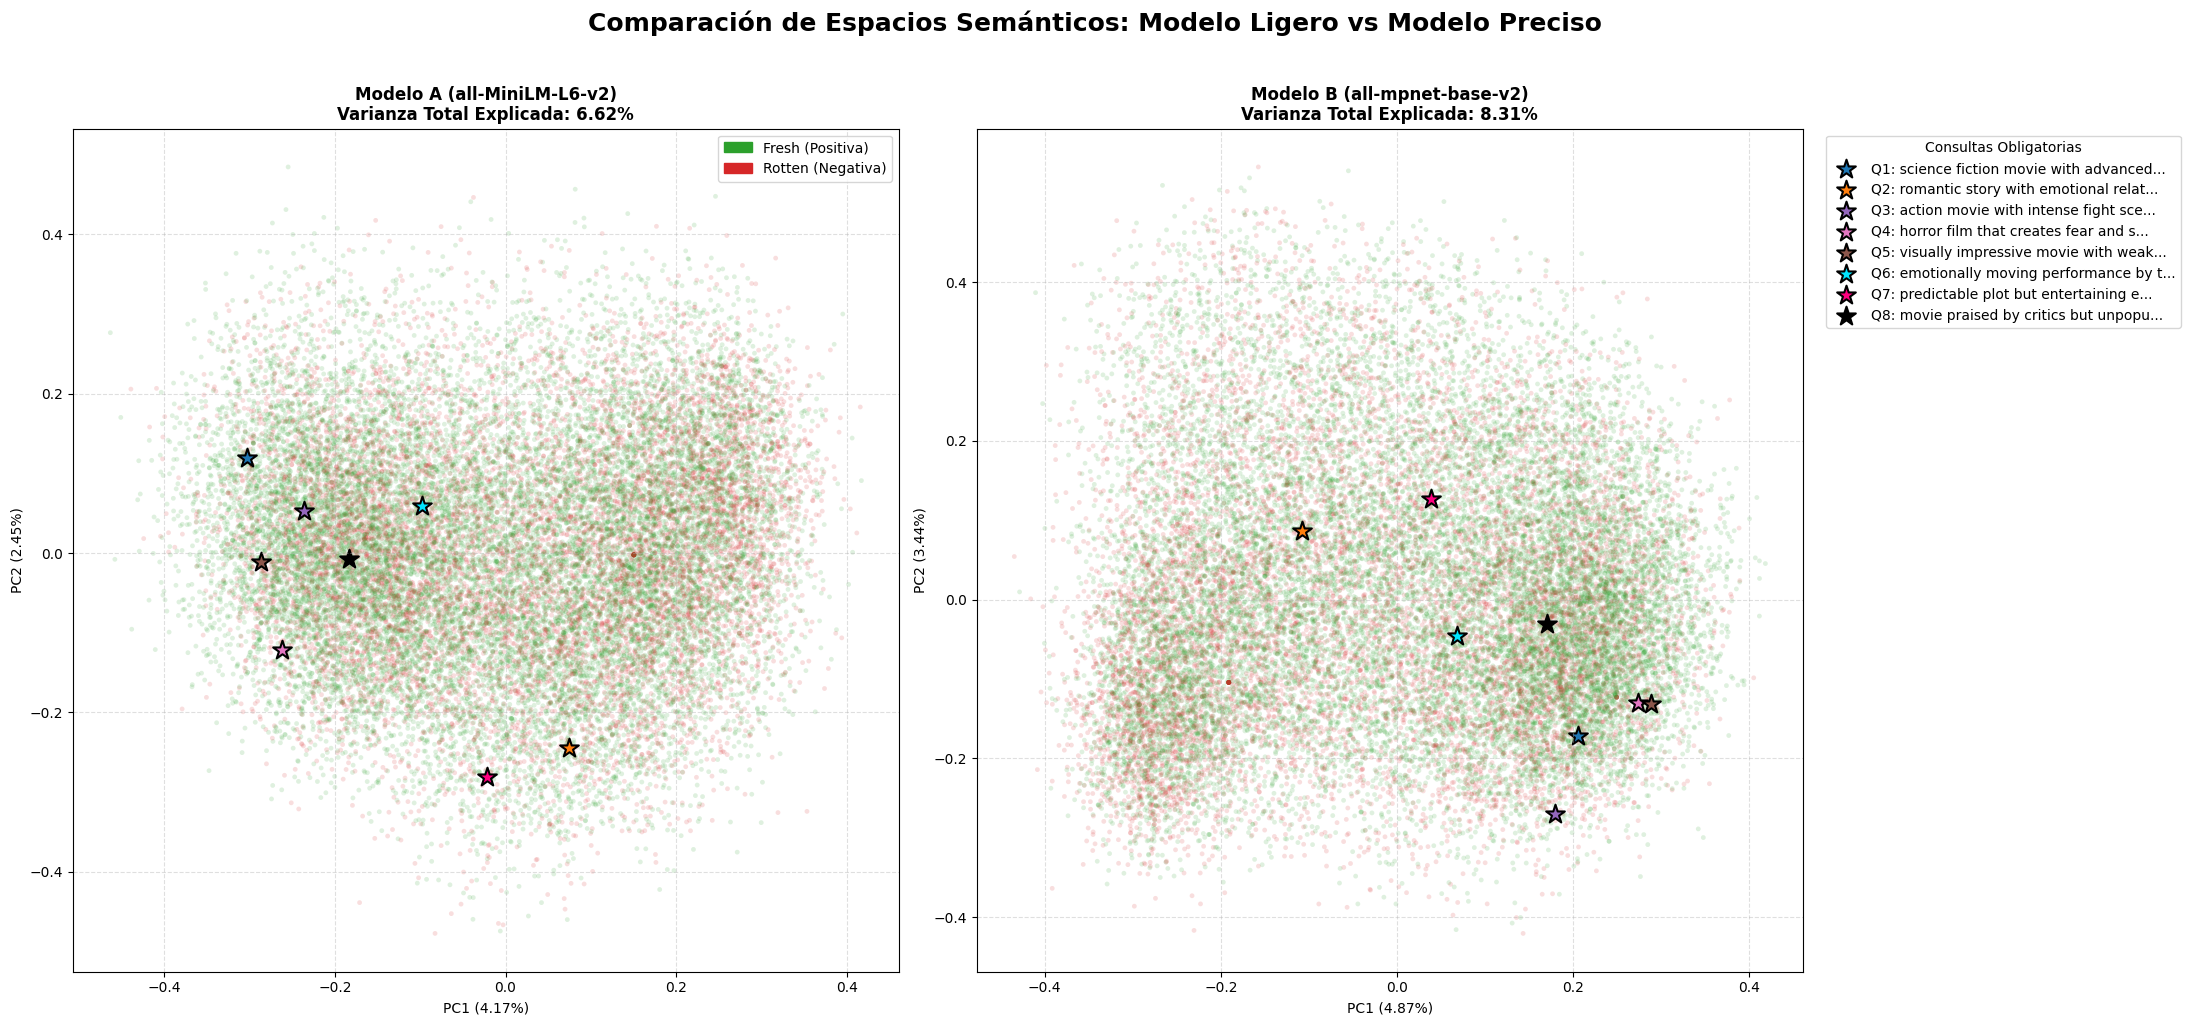

Métricas de Consistencia Matemática:
[Modelo A] Varianza retenida: PC1=4.17%, PC2=2.45% (Total: 6.62%)
[Modelo B] Varianza retenida: PC1=4.87%, PC2=3.44% (Total: 8.31%)


In [12]:
print("Generando embeddings para las 8 consultas en ambos modelos...")
embeddings_queries_a = []
embeddings_queries_b = []

for query in consultas_examen:
    clean_q = clean_text(query)
    # Vectores Modelo A (384D)
    embeddings_queries_a.append(model_a.encode([clean_q]).flatten())
    # Vectores Modelo B (768D)
    embeddings_queries_b.append(model_b.encode([clean_q]).flatten())

matrix_qa = np.vstack(embeddings_queries_a)
matrix_qb = np.vstack(embeddings_queries_b)

print("Calculando componentes principales (PCA) para Modelo A y Modelo B...")

# PCA para Modelo A
todas_estructuras_a = np.vstack([embeddings_a, matrix_qa])
pca_a = PCA(n_components=2, random_state=42)
coords_a = pca_a.fit_transform(todas_estructuras_a)
coords_docs_a = coords_a[:-8]
coords_queries_a = coords_a[-8:]
var_a = pca_a.explained_variance_ratio_

# PCA para Modelo B
todas_estructuras_b = np.vstack([embeddings_b, matrix_qb])
pca_b = PCA(n_components=2, random_state=42)
coords_b = pca_b.fit_transform(todas_estructuras_b)
coords_docs_b = coords_b[:-8]
coords_queries_b = coords_b[-8:]
var_b = pca_b.explained_variance_ratio_

print("Construyendo los gráficos de dispersión comparativos...")

# Crear una figura con 1 fila y 2 columnas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))
colores_docs = ['#2ca02c' if r_type == 'Fresh' else '#d62728' for r_type in df['review_type']]
colores_queries = ['#1f77b4', '#ff7f0e', '#9467bd', '#e377c2', '#8c564b', '#00e5ff', '#ff007f', '#000000']

# --- PANEL 1: MODELO A ---
ax1.scatter(coords_docs_a[:, 0], coords_docs_a[:, 1], alpha=0.15, c=colores_docs, s=12, edgecolors='none')
for idx, query in enumerate(consultas_examen):
    ax1.scatter(coords_queries_a[idx, 0], coords_queries_a[idx, 1], c=colores_queries[idx],
                s=200, marker='*', edgecolors='black', linewidths=1.5)

ax1.set_title(f'Modelo A (all-MiniLM-L6-v2)\nVarianza Total Explicada: {np.sum(var_a)*100:.2f}%', fontweight='bold')
ax1.set_xlabel(f'PC1 ({var_a[0]*100:.2f}%)')
ax1.set_ylabel(f'PC2 ({var_a[1]*100:.2f}%)')
ax1.grid(True, linestyle='--', alpha=0.4)

# --- PANEL 2: MODELO B ---
ax2.scatter(coords_docs_b[:, 0], coords_docs_b[:, 1], alpha=0.15, c=colores_docs, s=12, edgecolors='none')
for idx, query in enumerate(consultas_examen):
    ax2.scatter(coords_queries_b[idx, 0], coords_queries_b[idx, 1], c=colores_queries[idx],
                s=200, marker='*', edgecolors='black', linewidths=1.5, label=f'Q{idx+1}: {query[:35]}...')

ax2.set_title(f'Modelo B (all-mpnet-base-v2)\nVarianza Total Explicada: {np.sum(var_b)*100:.2f}%', fontweight='bold')
ax2.set_xlabel(f'PC1 ({var_b[0]*100:.2f}%)')
ax2.set_ylabel(f'PC2 ({var_b[1]*100:.2f}%)')
ax2.grid(True, linestyle='--', alpha=0.4)

# Leyenda de fondo (corpus)
green_patch = mpatches.Patch(color='#2ca02c', label='Fresh (Positiva)')
red_patch = mpatches.Patch(color='#d62728', label='Rotten (Negativa)')

# Colocamos la leyenda del corpus en el primer panel
ax1.legend(handles=[green_patch, red_patch], loc='upper right', fontsize=10)
# Colocamos la leyenda de las consultas fuera del segundo panel
ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title="Consultas Obligatorias", fontsize=10)

plt.suptitle('Comparación de Espacios Semánticos: Modelo Ligero vs Modelo Preciso', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Imprimir desglose de consistencia matemática
print(f"Métricas de Consistencia Matemática:")
print(f"[Modelo A] Varianza retenida: PC1={var_a[0]*100:.2f}%, PC2={var_a[1]*100:.2f}% (Total: {np.sum(var_a)*100:.2f}%)")
print(f"[Modelo B] Varianza retenida: PC1={var_b[0]*100:.2f}%, PC2={var_b[1]*100:.2f}% (Total: {np.sum(var_b)*100:.2f}%)")